# Analysis of Airplane Crashes and Fatalities

Database that keeps a historical record of civil aviation accidents from 1908 to recent years.

In [2]:
# -----------------------------
# Libraries
# -----------------------------

import pandas as pd

import zipfile    #To work with ZIP archives (compress/uncompress files).
import io         # To handle in-memory streams (like files, but in RAM)
import requests   # To download files or fetch data from the internet

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [21]:
# -----------------------------
#  Download & read CSV from ZIP
# -----------------------------

url = 'https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/W4%20Gen%20AI/W4D3/Airplane%20Crashes%20and%20Fatalities%20upto%202023.zip'

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
print("Files in the ZIP:", z.namelist())

df_raw = pd.read_csv(z.open('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv'), encoding="cp1252")

print("\nFirst 5 rows:")
display(df_raw.head())


Files in the ZIP: ['Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv']

First 5 rows:


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [25]:
print(f'Size of dataset: {df_raw.shape[0]} accidents  x {df_raw.shape[1]} columns')

print("\ncolumns names, nulls and data types\n")
print(df_raw.info())

Size of dataset: 4998 accidents  x 17 columns

columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4

None

In [5]:
# -----------------------------
# Select relevant columns
# -----------------------------

# Date: Date of the accident
# Aboard: Total number of people on board the aircraft
# Fatalities: Number of people who died on the aircraft
# Ground: Number of people who died on the ground as a result of the accident

cols = ['Date', 'Location', 'Aboard', 'Fatalities', 'Ground']
df = df_raw[cols].copy()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        4998 non-null   object 
 1   Location    4994 non-null   object 
 2   Aboard      4980 non-null   float64
 3   Fatalities  4990 non-null   float64
 4   Ground      4956 non-null   float64
dtypes: float64(3), object(2)
memory usage: 195.4+ KB
None


# Cleaning

In [6]:
# Convert date to datetime, resulting ok (no missing values)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].dtype)
print("Missing dates:", df["Date"].isna().sum())

datetime64[ns]
Missing dates: 0


In [24]:
# Extract Year
df["Year"] = df["Date"].dt.year
display(df[["Date", "Year"]].head())
print("\nYear range:", df["Year"].min(), "-", df["Year"].max())

,Date,Year
0,1908-09-17,1908
1,1909-09-07,1909
2,1912-07-12,1912
3,1913-08-06,1913
4,1913-09-09,1913



Year range: 1908 - 2023


In [8]:
# ==  missing values ==

missing_counts = df.isnull().sum()
missing_pct = ((missing_counts / len(df)) * 100).round(1)

missing = pd.DataFrame({
    'Missing Count': missing_counts,
     'Missing %': missing_pct
 }).query("`Missing Count` > 0").sort_values(by='Missing %', ascending=False)

display(missing)


,Missing Count,Missing %
Ground,42,0.8
Aboard,18,0.4
Fatalities,8,0.2
Location,4,0.1


In [9]:
# Strategy for handling Missing values (minimal (<1%).:

  # Ground fatalities  filled with 0, assuming most accidents did not involve victims on the ground.
  # missing values in Aboard or Fatalities are removed because they are essential for analyzing accident severity.
  # Missing locations are filled with "Not Available" to keep the records

df2 = df.copy()

df2["Ground"] = df2["Ground"].fillna(0)
df2 = df2.dropna(subset=["Aboard", "Fatalities"])
df2['Location'] = df2['Location'].fillna("Not Available")

print(f'N° Accidents before: {df.shape[0]}')
print(f'N° Accidents after: {df2.shape[0]}')

missing_counts = df2.isnull().sum()
print(missing_counts)


N° Accidents before: 4998
N° Accidents after: 4980
Date          0
Location      0
Aboard        0
Fatalities    0
Ground        0
Year          0
dtype: int64


In [26]:
# == duplicates==

dup_count = df2.duplicated().sum()
print(f"Duplicate rows : {dup_count}")

# no duplicates!


Duplicate rows : 0


In [11]:
# Convert flot to to integers
df2 = df2.astype({"Aboard": int, "Fatalities": int, "Ground": int})

In [12]:
# new 4 columns

# Survivors
df2["Survivors"] = df2["Aboard"] - df2["Fatalities"]

#  Survivor Rate
df2["Survivor_%"] = np.where(
    df2["Aboard"] > 0,
    (df2["Survivors"] / df2["Aboard"]) * 100,
    np.nan  # If there was no one on board, it is not calculated - protection against division by zero
)

#  Fatality Rate (just the people in the plane)
df2["Fatalities_%_plane"] = np.where(
    df2["Aboard"] > 0,
    (df2["Fatalities"] / df2["Aboard"]) * 100,
    np.nan  #  If there was no one on board, it is not calculated - protection against division by zero
)


#  Fatality Rate (including ground)
df2["Fatalities_%_plane+ground"] = np.where(
    df2["Aboard"] > 0,
    ((df2["Fatalities"] + df2["Ground"] ) / df2["Aboard"]) * 100,
    np.nan  #  If there was no one on board, it is not calculated - protection against division by zero
)


In [13]:
# == check data types ==
df2.dtypes

,0
Date,datetime64[ns]
Location,object
Aboard,int64
Fatalities,int64
Ground,int64
Year,int32
Survivors,int64
Survivor_%,float64
Fatalities_%_plane,float64
Fatalities_%_plane+ground,float64


In [23]:
# -----------------------------
# Check final dataset before analzing
# -----------------------------
print(f"Accidents: {df2.shape[0]} | Columns: {df2.shape[1]}")
print(df2.info())
display(df2.head())

Accidents: 4980 | Columns: 10
<class 'pandas.core.frame.DataFrame'>
Index: 4980 entries, 0 to 4997
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       4980 non-null   datetime64[ns]
 1   Location                   4980 non-null   object        
 2   Aboard                     4980 non-null   int64         
 3   Fatalities                 4980 non-null   int64         
 4   Ground                     4980 non-null   int64         
 5   Year                       4980 non-null   int32         
 6   Survivors                  4980 non-null   int64         
 7   Survivor_%                 4975 non-null   float64       
 8   Fatalities_%_plane         4975 non-null   float64       
 9   Fatalities_%_plane+ground  4975 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(1), int64(4), object(1)
memory usage: 408.5+ KB


None

,Date,Location,Aboard,Fatalities,Ground,Year,Survivors,Survivor_%,Fatalities_%_plane,Fatalities_%_plane+ground
0,1908-09-17,"Fort Myer, Virginia",2,1,0,1908,1,50.0,50.0,50.0
1,1909-09-07,"Juvisy-sur-Orge, France",1,1,0,1909,0,0.0,100.0,100.0
2,1912-07-12,"Atlantic City, New Jersey",5,5,0,1912,0,0.0,100.0,100.0
3,1913-08-06,"Victoria, British Columbia, Canada",1,1,0,1913,0,0.0,100.0,100.0
4,1913-09-09,Over the North Sea,20,14,0,1913,6,30.0,70.0,70.0


# Exploratory data analysis

In [15]:
# basic statistics
print(f'\n{df2.shape[0]} Accidents between {df2["Year"].min()} & {df2["Year"].max()}')

print (f'\nAverage Accidents per year: {df2.shape[0] / (df2["Year"].max() - df2["Year"].min()):.2f}')

print("\nTotal Fatalities (not incuding ground):", f"{df2['Fatalities'].sum():,}")

print("\nTotal Fatalities (including ground):", f"{df2['Fatalities'].sum() + df2['Ground'].sum():,}")

print("\nAverage Survival Rate: {:.2f}%".format(df2["Survivor_%"].mean()))

print("\nAverage Fatalities Rate (plane): {:.2f}%".format(df2["Fatalities_%_plane"].mean()))

print("\nAverage Fatalities Rate (plane + ground): {:.2f}%".format(df2["Fatalities_%_plane+ground"].mean()))




4980 Accidents between 1908 & 2023

Average Accidents per year: 43.30

Total Fatalities (not incuding ground): 111,561

Total Fatalities (including ground): 120,071

Average Survival Rate: 18.15%

Average Fatalities Rate (plane): 81.85%

Average Fatalities Rate (plane + ground): 96.81%


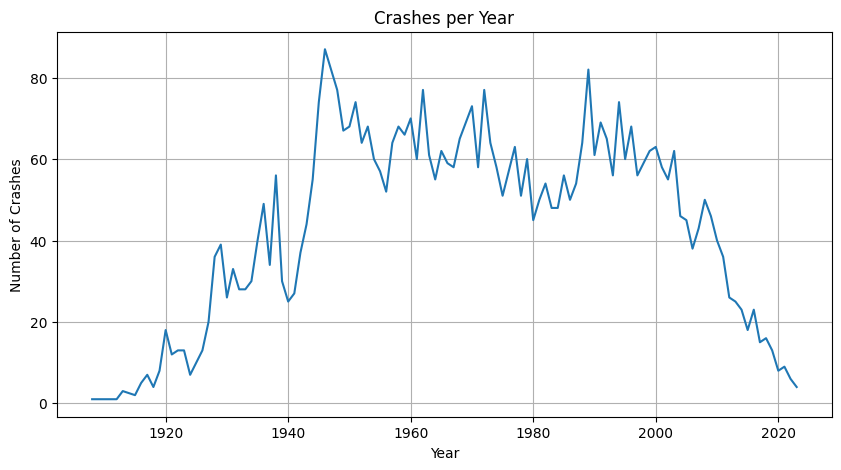

A peak in accidents is observed in the early 1940s, followed by a marked reduction from the 1990s onwards.


In [16]:
#frequency of crashes over time to identify any trend

crashes_per_year = df2.groupby("Year").size()

plt.figure(figsize=(10,5))
sns.lineplot(x=crashes_per_year.index, y=crashes_per_year.values)
plt.title("Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.grid(True)
plt.show()

print("A peak in accidents is observed in the early 1940s, followed by a marked reduction from the 1990s onwards.")


# Statistical Analysis

In [17]:
# Fatalities
fatalities = df2['Fatalities']
fatalities_desc = stats.describe(fatalities)

median_fatalities = np.median(fatalities)   # median and Standard deviation not included in scipy
std_fatalities = np.sqrt(fatalities_desc.variance)

print("=== Fatalities ===")
print(f"Mean: {fatalities_desc.mean:.2f}")
print(f"Median: {median_fatalities:.2f}")
print(f"Standard deviation: {std_fatalities:.2f}")
print(f"Skewness: {stats.skew(fatalities):.2f}")
print(f"Kurtosis: {stats.kurtosis(fatalities):.2f}\n")

print()

# Survivor rate
survivor_rate = df2['Survivor_%'].dropna()  # Ignore NaN
surv_desc = stats.describe(survivor_rate)

median_surv = np.median(survivor_rate)    # median and Standard deviation not included in scipy
std_surv = np.sqrt(surv_desc.variance)

print("=== Survivor Rate (%) ===")
print(f"Mean: {surv_desc.mean:.2f}")
print(f"Median: {median_surv:.2f}")
print(f"Standard deviation: {std_surv:.2f}")
print(f"Skewness: {stats.skew(survivor_rate):.2f}")
print(f"Kurtosis: {stats.kurtosis(survivor_rate):.2f}")


=== Fatalities ===
Mean: 22.40
Median: 11.00
Standard deviation: 35.09
Skewness: 4.60
Kurtosis: 36.54


=== Survivor Rate (%) ===
Mean: 18.15
Median: 0.00
Standard deviation: 31.17
Skewness: 1.55
Kurtosis: 0.90


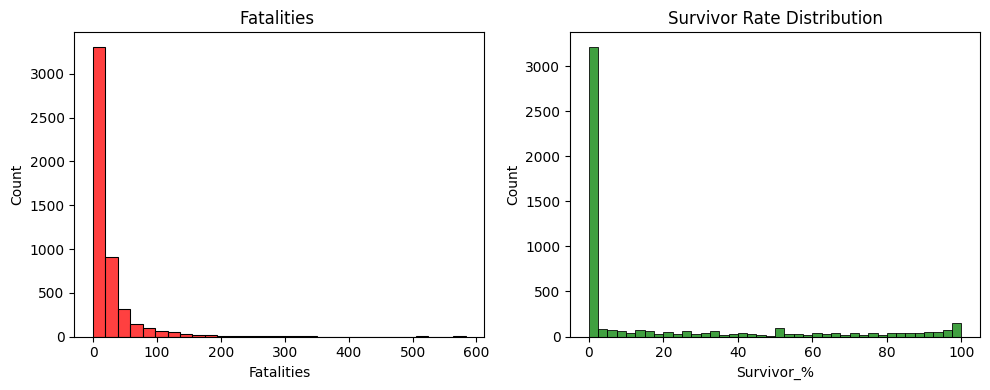

In [18]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df2['Fatalities'], bins=30, color='red')
plt.title("Fatalities ")

plt.subplot(1,2,2)
sns.histplot(df2['Survivor_%'].dropna(), bins=40, color='green')
plt.title("Survivor Rate Distribution")

plt.tight_layout()
plt.show()

## **Fatalities**

Most accidents are relatively small, but there are some extreme cases that raise the mean and dispersion.

* On average, each accident has about 22 fatalities.

* Half of the accidents have 11 or fewer fatalities (accidents with many victims raise the average).

* The dispersion is very high; accidents vary greatly in the number of victims.

* Skewness = 4.60: Very skewed to the right → there are few accidents with many victims, but most accidents have few victims.

* Kurtosis = 36.54: Extremely peaked distribution with very long tails → there are rare but very large extreme values, such as catastrophic accidents with  hundreds of victims.

## **Survivor Rate (%)**

It is highly variable: there are fatal accidents, but some have survivors, resulting in a low average with high dispersion.

- The average number of survivors per accident is low because it includes accidents where there was no one on board or where everyone died.

- More than half of the accidents have 0% survivors, meaning total fatalities.

- There is a lot of variability; some accidents have all survivors, others none.

- Skewness = 1.55: Positive skewness, although less extreme than in fatalities → accidents with many survivors raise the average.

- Kurtosis = 0.90: Relatively flat distribution compared to a normal distribution → no extreme tails as pronounced as in fatalities, but there is a lot of dispersion.


Step 1: State hypothesis
  H0: mean fatalities '40s == mean fatalities '90s
  H1: mean fatalities '40s != mean fatalities '90s
  α = 0.05

Step 2: Examine the groups
  40s' : n=575, mean=15.445, std=10.960
  90s' : n=630, mean=25.370, std=41.520
 Observed difference: 9.925

Step 3: Run the test
 t-statistic: -5.783
 p-value: 0.00000

Step 4: Decision
There is a significant difference in the average number of fatalities between '40s and '90s.



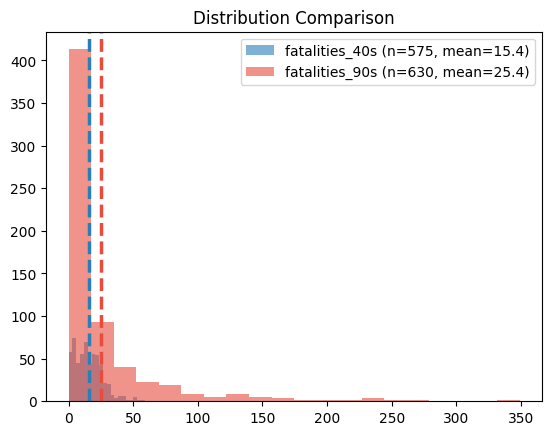

In [19]:
# hypothesis test: comparing the average number of fatalities (people in the plane) in decades:
#  '40s → aviation expansion + WWII
#  '90s → modern aviation era

fatalities_40s = df2[(df2['Year'] >= 1940) & (df2['Year'] < 1950)]['Fatalities']   #'40s
fatalities_90s = df2[(df2['Year'] >= 1990) & (df2['Year'] < 2000)]['Fatalities']   #'90s



alpha = 0.05

print("\nStep 1: State hypothesis")
print(f"  H0: mean fatalities '40s == mean fatalities '90s")
print(f"  H1: mean fatalities '40s != mean fatalities '90s")
print(f"  α = 0.05")

print("\nStep 2: Examine the groups")
print(f"  40s' : n={len(fatalities_40s)}, mean={np.mean(fatalities_40s):.3f}, std={np.std(fatalities_40s, ddof=1):.3f}")
print(f"  90s' : n={len(fatalities_90s)}, mean={np.mean(fatalities_90s):.3f}, std={np.std(fatalities_90s, ddof=1):.3f}")
print(f" Observed difference: {np.mean(fatalities_90s) - np.mean(fatalities_40s):.3f}")

print("\nStep 3: Run the test")   # T-test ind
t_stat, p_value = stats.ttest_ind(fatalities_40s, fatalities_90s, equal_var=False)  #use Welch's t-test, equal_var=False, unless you have a specific reason to believe they are equal
print(f" t-statistic: {t_stat:.3f}")
print(f" p-value: {p_value:.5f}")

print("\nStep 4: Decision")

if p_value < alpha:
   print("There is a significant difference in the average number of fatalities between '40s and '90s.")
else:
    print("There is no significant difference in the average number of fatalities between '40s and '90s.")

print()

# Histogram
plt.hist(fatalities_40s, bins=20, alpha=0.6, color="#2980B9", label=f"fatalities_40s (n={len(fatalities_40s)}, mean={np.mean(fatalities_40s):.1f})")
plt.hist(fatalities_90s, bins=20, alpha=0.6, color="#E74C3C", label=f"fatalities_90s (n={len(fatalities_90s)}, mean={np.mean(fatalities_90s):.1f})")
plt.axvline(np.mean(fatalities_40s), color="#2980B9", lw=2.5, linestyle="--")
plt.axvline(np.mean(fatalities_90s), color="#E74C3C", lw=2.5, linestyle="--")
plt.title("Distribution Comparison")
plt.legend()


Possible explanation

While air safety improved over time, the total number of flights was much higher during the '90s compared to the '40s.

This is why the average number of fatalities is reported as higher.

In addition, a few serious accidents with many victims can skew the average, making the number of fatalities appear higher.

# Visualization:

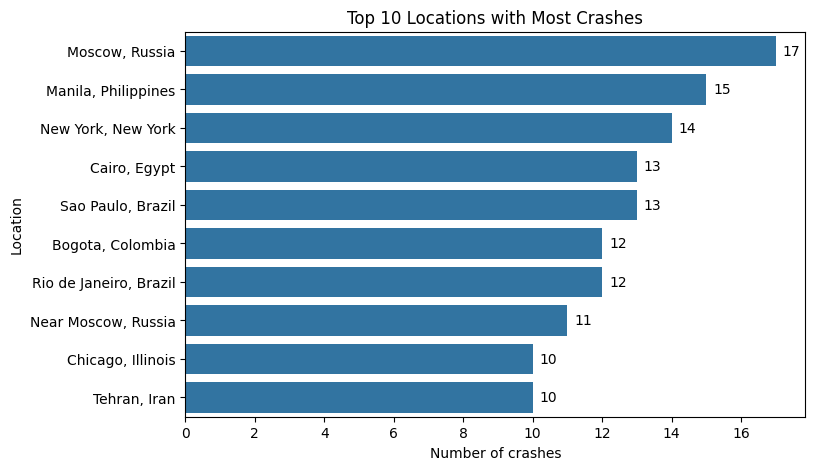

In [27]:
top_locations = df2['Location'].value_counts().head(10)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 Locations with Most Crashes")
plt.xlabel("Number of crashes")

for i, v in enumerate(top_locations.values):
    ax.text(v + 0.2, i, str(v), va='center')

plt.show()

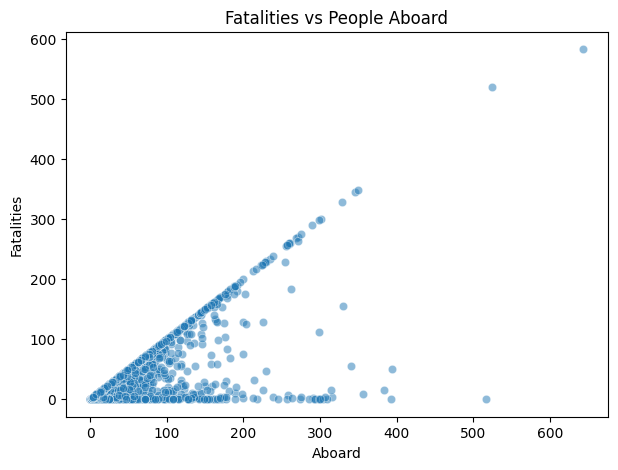


Accidents with more passengers produce higher fatalities, but the relationship is not perfectly linear.


In [94]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df2, x="Aboard", y="Fatalities", alpha=0.5)
plt.title("Fatalities vs People Aboard")
plt.show()
print('\nAccidents with more passengers produce higher fatalities, but the relationship is not perfectly linear.')

In [95]:
# aggregation by year
yearly = df2.groupby("Year").agg(
    Aboard=("Aboard","sum"),
    Fatalities=("Fatalities","sum"),
    Ground=("Ground","sum"),
    Survivors=("Survivors","sum"),
    survivor_rate=("Survivor_%","mean"),
    fatality_rate_plane=("Fatalities_%_plane","mean"),
    fatality_rate_total=("Fatalities_%_plane+ground","mean")
)

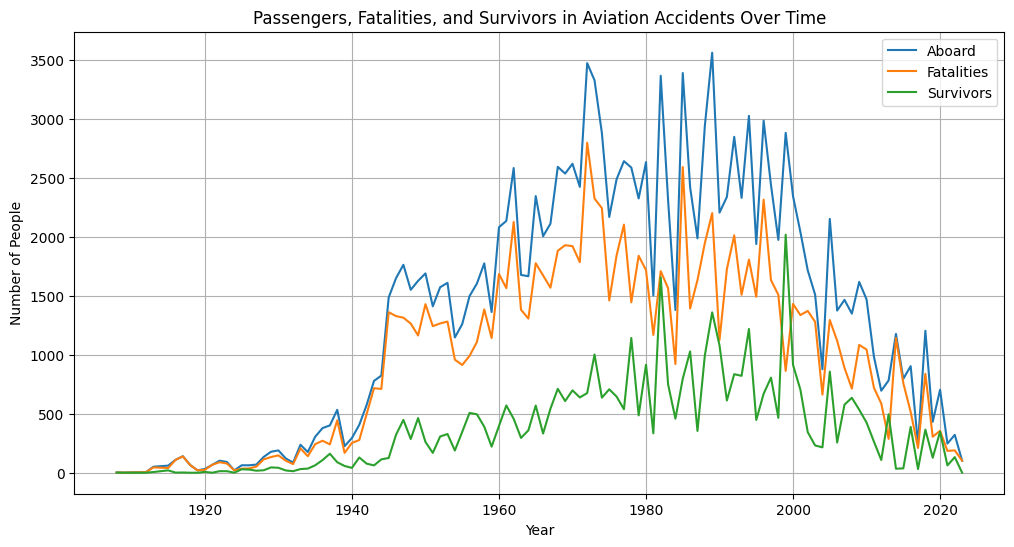

In [96]:
# over time

plt.figure(figsize=(12,6))

plt.plot(yearly.index, yearly["Aboard"], label="Aboard")
plt.plot(yearly.index, yearly["Fatalities"], label="Fatalities")
plt.plot(yearly.index, yearly["Survivors"], label="Survivors")

plt.title("Passengers, Fatalities, and Survivors in Aviation Accidents Over Time")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.legend()
plt.grid(True)

plt.show()

#Aboard
#The number of people involved in accidents has increased over time due to the growth of the aviation industry - there is a remarkable peak due to WWII-
# and the larger capacity of modern aircraft.

# Fatalities
# Do not increase as the same speed as the number of passengers, suggesting improvements in aviation safety.

# Survivors
#Over time, a larger number of passengers surviving accidents show significant improvements in safety systems and emergency response procedures.


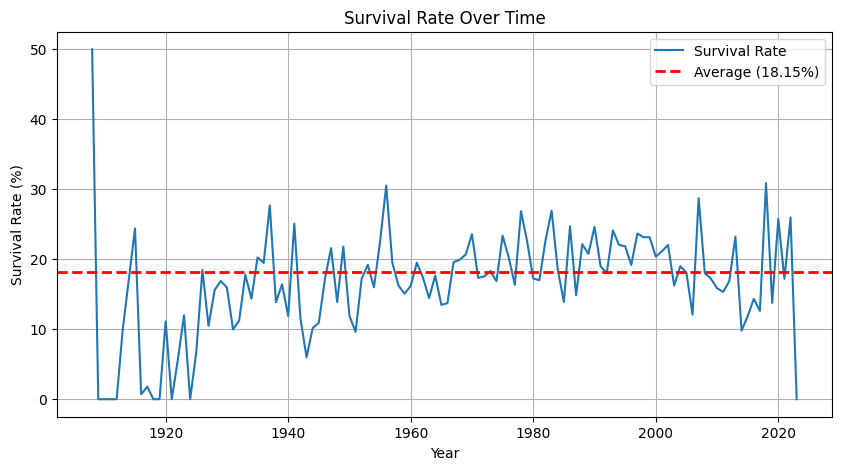

In [101]:
# Survival rates hovers 20% most of the years (Mean: 18.15).

plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly["survivor_rate"], label="Survival Rate")
mean_surv = df2["Survivor_%"].mean()
plt.axhline(mean_surv, color='red', linestyle='--', linewidth=2, label=f"Average ({mean_surv:.2f}%)")

plt.title("Survival Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Survival Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

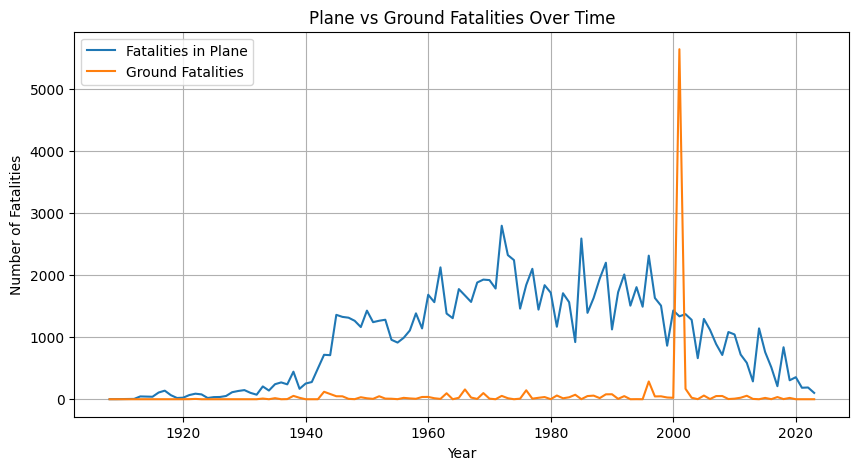

,Date,Location,Aboard,Fatalities,Ground,Year,Survivors,Survivor_%,Fatalities_%_plane,Fatalities_%_plane+ground
4328,2001-09-11,"New York City, New York",92,92,2750,2001,0,0.0,100.0,3089.130435
4329,2001-09-11,"New York City, New York",65,65,2750,2001,0,0.0,100.0,4330.769231


In [98]:
# Deaths on land are relatively rare compared to deaths on board.
# But there is a remarkable exception: the attack on the Twin Towers in September 2001 in New York.

plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly["Fatalities"], label="Fatalities in Plane")
plt.plot(yearly.index, yearly["Ground"], label="Ground Fatalities")

plt.title("Plane vs Ground Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.legend()
plt.grid(True)

plt.show()


acc_911 = df2[(df2["Date"] == "2001-09-11") &
              (df2["Location"] == "New York City, New York")]

display(acc_911)


# Key Findings

1.   Crashes peaked in the 1940s (wartime effect).
2.   Accidents declined significantly since the 1990s (improved safety).
3. Fatalities are highly skewed: few deaths per accident, rare catastrophes drive the average.
4. Over half of accidents have 0% survivors.
5. Average fatalities per accident differ across decades.
6. Outlier in ground fatalities 9/11 = example of historical anomaly.